In [ ]:
# CREATING DATASET

In [2]:
import pandas as pd
import numpy as np

# Set random seed
np.random.seed(42)

# Number of rows
n = 500

data = {
    "income": np.random.randint(20000, 100000, n),
    "debt": np.random.randint(0, 50000, n),
    "payment_history": np.random.randint(0, 2, n),  # 0 = bad, 1 = good
    "loan_amount": np.random.randint(5000, 50000, n),
}

df = pd.DataFrame(data)

# Feature Engineering
df["debt_income_ratio"] = df["debt"] / (df["income"] + 1)

# Create target (simple logic)
df["target"] = (
    (df["income"] > 40000) &
    (df["debt_income_ratio"] < 0.5) &
    (df["payment_history"] == 1)
).astype(int)

# Save dataset
df.to_csv("credit_data.csv", index=False)

print("Dataset created successfully!")
print(df.head())

Dataset created successfully!
   income   debt  payment_history  loan_amount  debt_income_ratio  target
0   35795   1167                0         9090           0.032601       0
1   20860  27192                0        11960           1.303485       0
2   96820   1062                0        40772           0.010969       0
3   74886  18540                1        26520           0.247573       1
4   26265  24244                1        41408           0.923018       0


In [ ]:
# LOADING THE DATASET

In [4]:
import pandas as pd

df = pd.read_csv("credit_data.csv")
print(df.head())

   income   debt  payment_history  loan_amount  debt_income_ratio  target
0   35795   1167                0         9090           0.032601       0
1   20860  27192                0        11960           1.303485       0
2   96820   1062                0        40772           0.010969       0
3   74886  18540                1        26520           0.247573       1
4   26265  24244                1        41408           0.923018       0


In [ ]:
# ML MODEL CODE


Model Comparison:

Logistic Regression
accuracy: 0.970
precision: 1.000
recall: 0.906
f1: 0.951
roc_auc: 0.995

Decision Tree
accuracy: 0.990
precision: 1.000
recall: 0.969
f1: 0.984
roc_auc: 0.984

Random Forest
accuracy: 0.990
precision: 1.000
recall: 0.969
f1: 0.984
roc_auc: 1.000

Best Model: Random Forest

Confusion Matrix:
[[68  0]
 [ 1 31]]


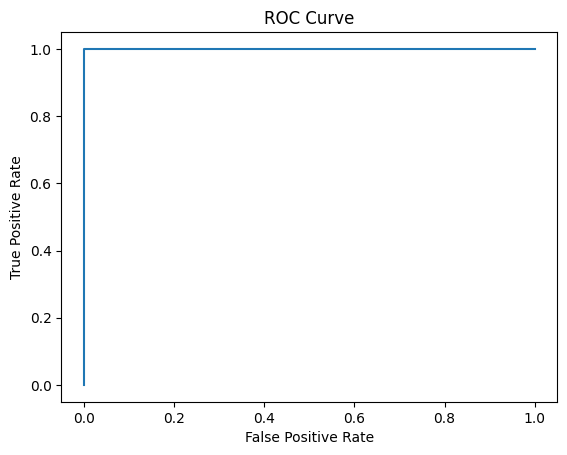


Model saved as credit_model.pkl


In [6]:
# ======================================
# 1. Import Libraries
# ======================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib

# ======================================
# 2. Load Dataset
# ======================================
df = pd.read_csv("credit_data.csv")

# ======================================
# 3. Features & Target
# ======================================
X = df.drop("target", axis=1)
y = df["target"]

# ======================================
# 4. Train-Test Split
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ======================================
# 5. Scaling
# ======================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# 6. Models
# ======================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

# ======================================
# 7. Training & Evaluation
# ======================================
for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }

# ======================================
# 8. Show Comparison
# ======================================
print("\nModel Comparison:")
for name, res in results.items():
    print(f"\n{name}")
    for metric, value in res.items():
        print(f"{metric}: {value:.3f}")

# ======================================
# 9. Find Best Model
# ======================================
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
print("\nBest Model:", best_model_name)

best_model = models[best_model_name]

# ======================================
# 10. Confusion Matrix
# ======================================
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# ======================================
# 11. ROC Curve
# ======================================
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# ======================================
# 12. Save Model
# ======================================
joblib.dump(best_model, "credit_model.pkl")
print("\nModel saved as credit_model.pkl")

In [ ]:
# OWN INPUT TO PREDICT THE OUTPUT

In [7]:
sample = pd.DataFrame({
    "income": [50000],
    "debt": [10000],
    "payment_history": [1],
    "loan_amount": [20000],
    "debt_income_ratio": [10000/50000]
})

sample_scaled = scaler.transform(sample)

prediction = best_model.predict(sample_scaled)

print("Final Result:", "Good Credit" if prediction[0] == 1 else "Bad Credit")

Final Result: Good Credit
